# Phase A & B Validation: TravelGraph & Temporal Simulation
This notebook provides visual validations for the core architectural components of the Jeepney Routing System:
1. **Three-Layer Graph Architecture**: Renders individual projections of the six edge transitions (SW, WA, RI, AL, EW, TR) that bridge pedestrian streets and jeepney routes.
2. **Sample Journey**: Finds a shortest journey requiring a route-to-route transfer and visualizes it along the 3D travel graph.
3. **Temporal Simulation Visualizer**: Runs the simulation step-by-step and maps active jeepneys and passengers (waiting and riding) across ticks, validating the physics of agent boarding and route progression.

In [6]:
import os
import random
import yaml
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from utils_simplified import (
    reuse_citygraph,
    reuse_ddm,
    generate_route_system,
    generate_dummy_yaml,
    build_travelgraph,
    run_simulation_env,
    SimEnvironment
)
from utils.jeep import Jeep
from utils.jeep_system import JeepSystem
from utils.travel_graph_3d_vis import TravelGraph3DVisualizer

# Load the pre-compiled static environment data
cg = reuse_citygraph("results_and_discussion/pkl/profile_p1.pkl")
ddm = reuse_ddm("results_and_discussion/pkl/ddm_8am.pkl")

# Generate 2 non-overlapping routes (no shared nodes) just for the sake of the journey generation
def generate_non_overlapping_routes(cg, ddm, n_routes=2, max_attempts=50):
    for attempt in range(max_attempts):
        routes = generate_route_system(n_routes, cg, ddm)
        node_sets = [
            {(e.start.lon, e.start.lat) for e in r.path} |
            {(e.end.lon, e.end.lat) for e in r.path}
            for r in routes
        ]
        if all(
            node_sets[i].isdisjoint(node_sets[j])
            for i in range(n_routes)
            for j in range(i + 1, n_routes)
        ):
            print(f"Found non-overlapping routes on attempt {attempt + 1}.")
            return routes
    raise RuntimeError(f"Could not find {n_routes} non-overlapping routes in {max_attempts} attempts.")

routes = generate_non_overlapping_routes(cg, ddm)
print("Environment successfully loaded.")

[INFO] Reusing CityGraph from pickle file: results_and_discussion/pkl/profile_p1.pkl


[INFO] Reusing DirectDemandSampler from pickle file: results_and_discussion/pkl/ddm_8am.pkl
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] Generating 2 routes...
[INFO] G

### TravelGraph Construction
We build a dummy configuration profile and construct a 3-layer `TravelGraph` that combines walkable city paths with our route system configurations.

In [7]:
yaml_path = "configs/dummy_nb1.yaml"
generate_dummy_yaml(yaml_path, **{
    "simulation.num_ticks": 200,
    "simulation.total_allocatable_jeeps": 25,
    "cg_pkl": "results_and_discussion/pkl/profile_p1.pkl",
    "ddm_pkl": "results_and_discussion/pkl/ddm_8am.pkl",
    "travel_graph.transfer_wt": 15.0
})

tg = build_travelgraph(cg, yaml_path, routes)
print(f"TravelGraph built: {len(tg.travel_graph)} transitions.")

[INFO] Generating dummy YAML at configs/dummy_nb1.yaml with overrides: {'simulation.num_ticks': 200, 'simulation.total_allocatable_jeeps': 25, 'cg_pkl': 'results_and_discussion/pkl/profile_p1.pkl', 'ddm_pkl': 'results_and_discussion/pkl/ddm_8am.pkl', 'travel_graph.transfer_wt': 15.0}
[INFO] Building TravelGraph using config from: configs/dummy_nb1.yaml
TravelGraph built: 200275 transitions.


## 1. Three-Layer Graph Visualizations (Six Illustrations)
We use the 3D travel graph visualizer to render projections of the six individual transition edge types:
*   **SW (Start Walk)**: Red edges connecting Layer 1 (walking network) to Layer 2 (stop/boarding gate).
*   **WA (Wait)**: Orange edges representing waiting time penalty inside Layer 2.
*   **RI (Ride)**: Yellow edges representing vehicle movement along jeepney routes in Layer 3.
*   **AL (Alight)**: Green edges connecting Layer 3 back down to Layer 1 (alighting stop).
*   **EW (End Walk)**: Blue edges connecting Layer 1 stop coordinates to destination locations.
*   **TR (Transfer)**: Teal edges connecting Layer 3 Stop Node of one route to Layer 2 Wait Node of another route (representing passenger transfer).


--- Rendering Start Walk (SW) - Layer 1 (Walk) to Layer 2 (Wait) ---


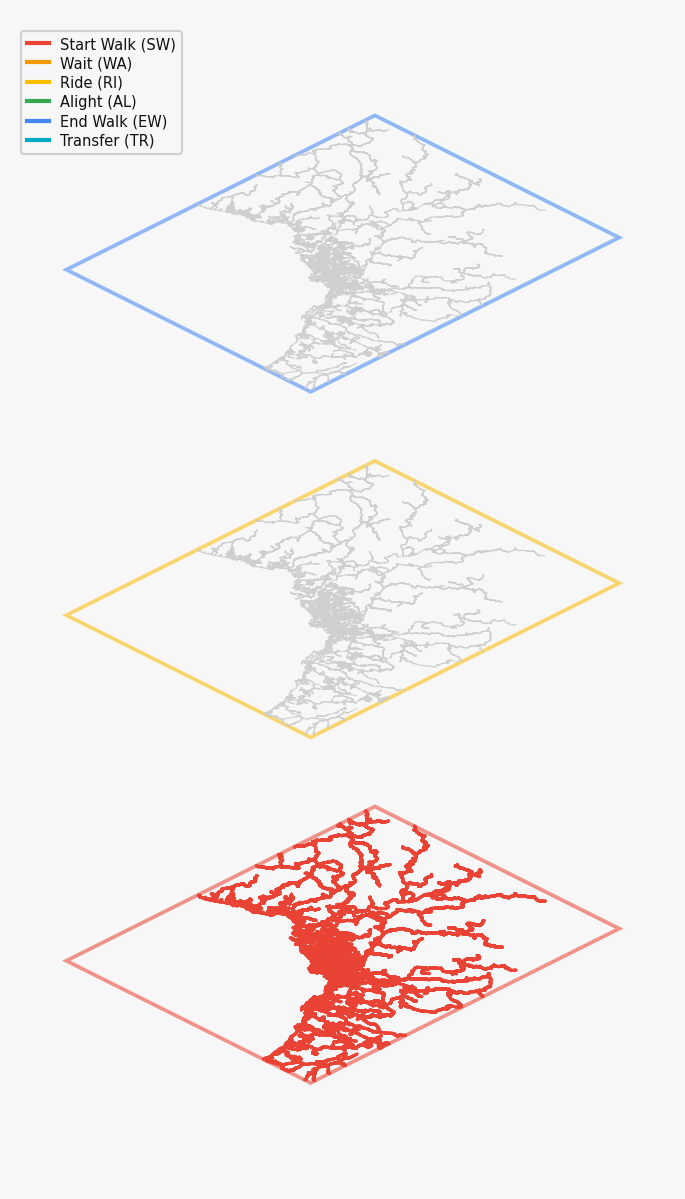


--- Rendering Wait (WA) - Layer 2 (Wait) to Layer 3 (Ride) ---


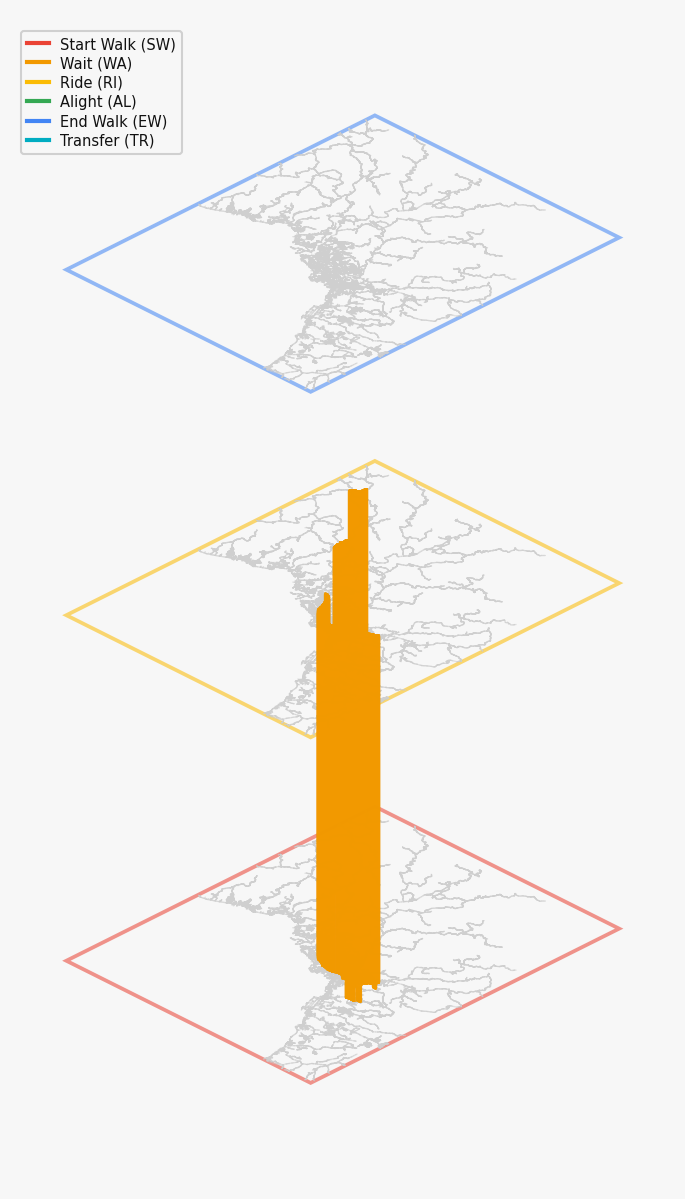


--- Rendering Ride (RI) - Layer 3 (Ride) Transit Edges ---


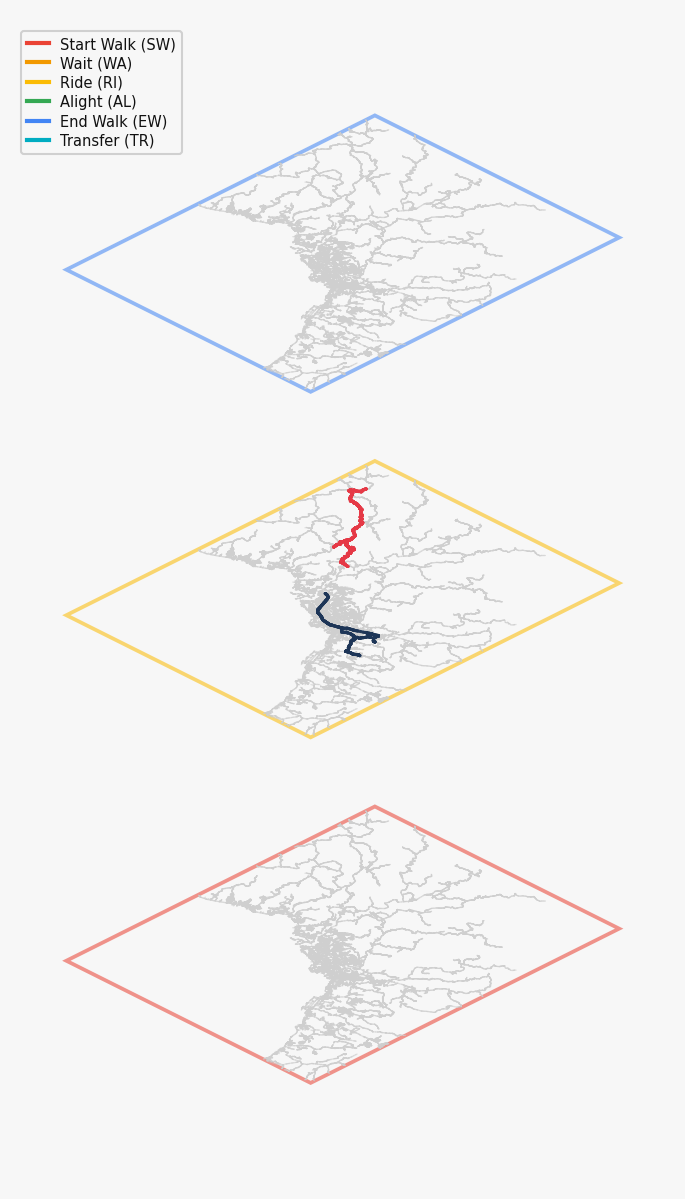


--- Rendering Alight (AL) - Layer 3 (Ride) to Layer 1 (Walk) ---


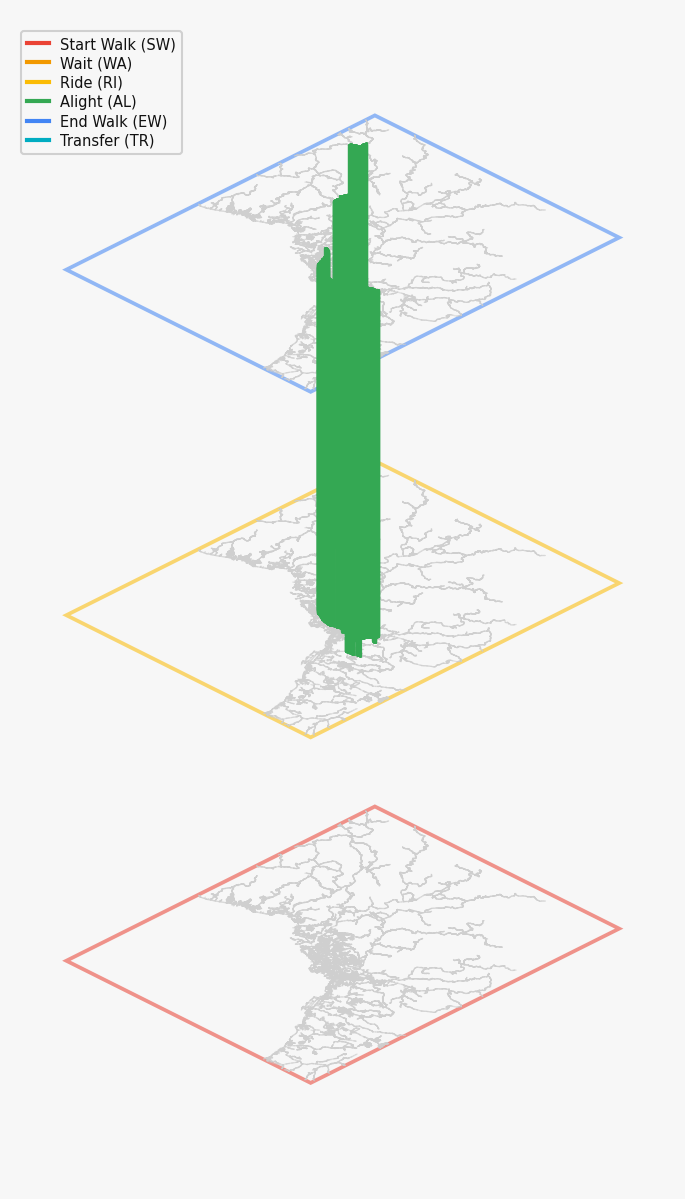


--- Rendering End Walk (EW) - Layer 1 Stop to Layer 1 Destination ---


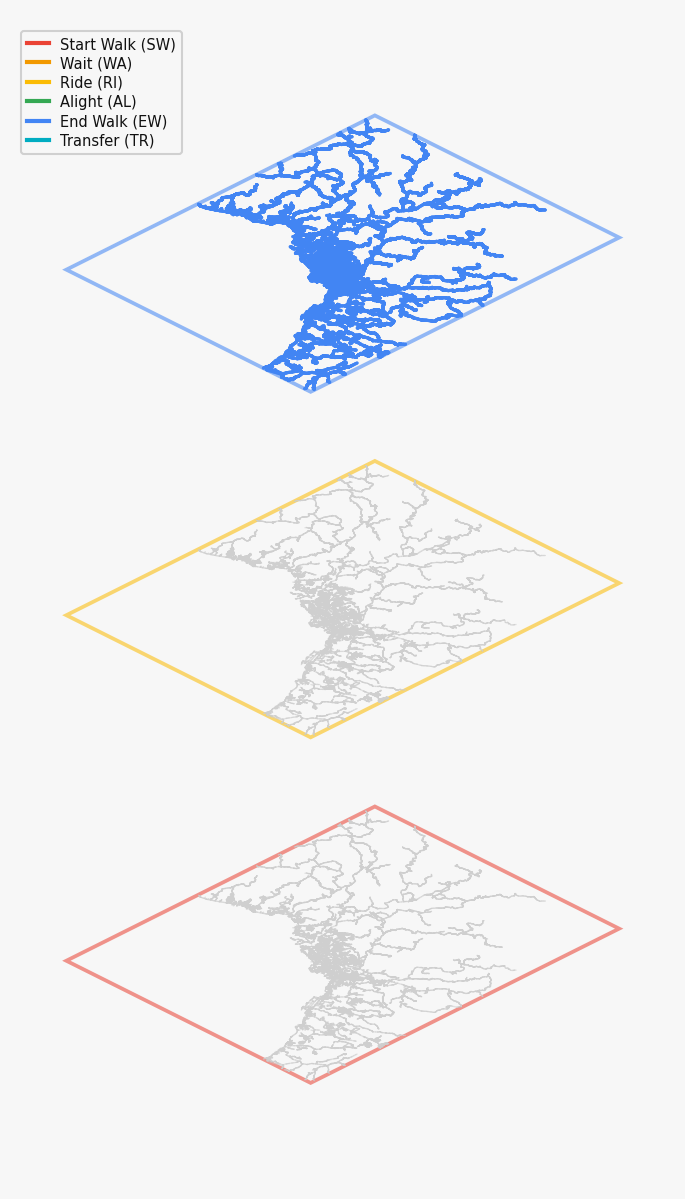


--- Rendering Transfer (TR) - Layer 3 to Layer 2 stop of another route ---


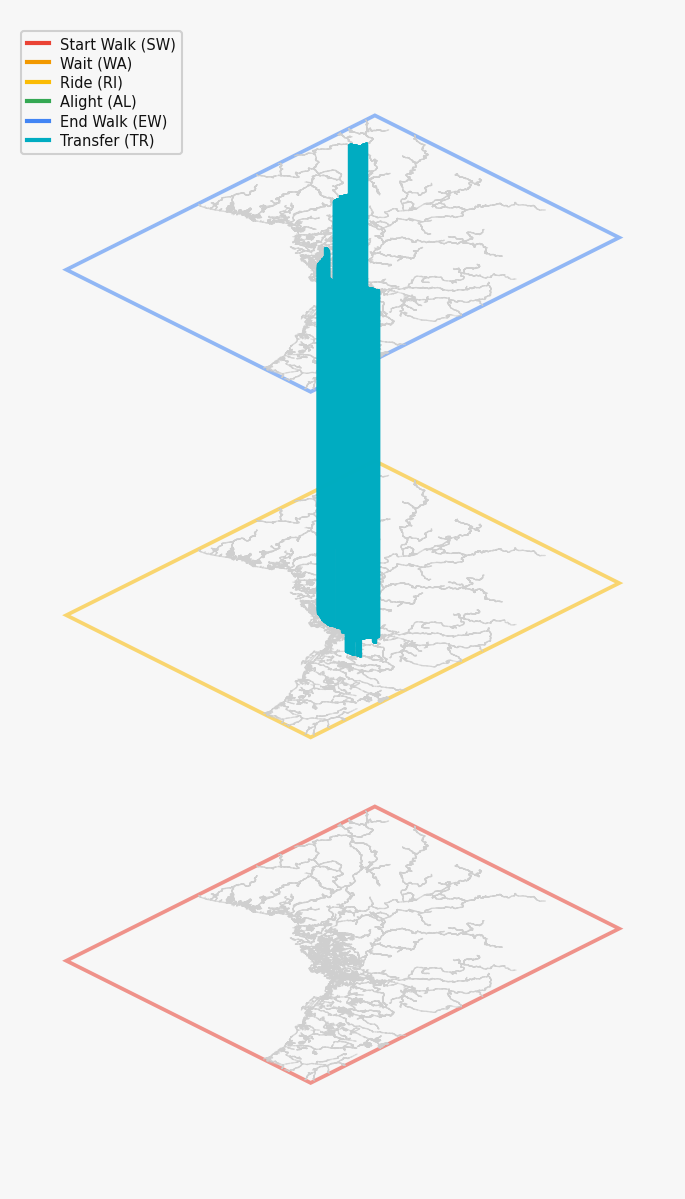

In [3]:
# highlight_edges=[] — no journey path to overlay; passing tg.travel_graph here
# caused the entire graph to be re-drawn at journey_thickness on top of itself (Bug 1 & 2).
visualizer = TravelGraph3DVisualizer(tg.travel_graph, highlight_edges=[], mode="light_nolabels", edge_thickness=1.5, journey_thickness=3.0, node_radius=20)

edge_types = [
    ("SW", "Start Walk (SW) - Layer 1 (Walk) to Layer 2 (Wait)"),
    ("WA", "Wait (WA) - Layer 2 (Wait) to Layer 3 (Ride)"),
    ("RI", "Ride (RI) - Layer 3 (Ride) Transit Edges"),
    ("AL", "Alight (AL) - Layer 3 (Ride) to Layer 1 (Walk)"),
    ("EW", "End Walk (EW) - Layer 1 Stop to Layer 1 Destination"),
    ("TR", "Transfer (TR) - Layer 3 to Layer 2 stop of another route"),
]

os.makedirs("results_and_discussion/images", exist_ok=True)

for prefix, name in edge_types:
    print(f"\n--- Rendering {name} ---")
    img = visualizer.draw(
        display_walk=(prefix == "SW"),
        display_wait=(prefix == "WA"),
        display_ride=(prefix == "RI"),
        display_alight=(prefix == "AL"),
        display_end_walk=(prefix == "EW"),
        display_transfer=(prefix == "TR"),
        display_direct=False,
        legend_on=True  # Bug 3 fix: was False, suppressing the legend
    )
    img.save(f"results_and_discussion/images/layer_transition_{prefix}.png")
    display(img)

## 2. Sample Journey (Featuring a Transfer)
We stochastically search for a passenger travel journey that involves a transfer between two jeepney routes. Once found, we print its transition nodes and highlight it inside the 3D travel graph.

Searching for a journey containing a transfer...
Found a valid transfer journey with 1181 edge transitions!
  Segment 1: SW57954              | Cost: 3.47 EIVM
  Segment 2: SW57952              | Cost: 2.74 EIVM
  Segment 3: SW57950              | Cost: 2.90 EIVM
  Segment 4: SW57948              | Cost: 10.15 EIVM
  Segment 5: SW57946              | Cost: 15.67 EIVM
  Segment 6: SW57944              | Cost: 15.34 EIVM
  Segment 7: SW57942              | Cost: 3.14 EIVM
  Segment 8: SW57940              | Cost: 2.24 EIVM
  Segment 9: SW57938              | Cost: 1.93 EIVM
  Segment 10: SW57936              | Cost: 2.60 EIVM
  Segment 11: SW57934              | Cost: 3.32 EIVM
  Segment 12: SW57932              | Cost: 3.43 EIVM
  Segment 13: SW57930              | Cost: 2.17 EIVM
  Segment 14: SW57928              | Cost: 8.95 EIVM
  Segment 15: SW57926              | Cost: 5.38 EIVM
  Segment 16: SW57924              | Cost: 5.45 EIVM
  Segment 17: SW57922              | Cost: 2.68 EI

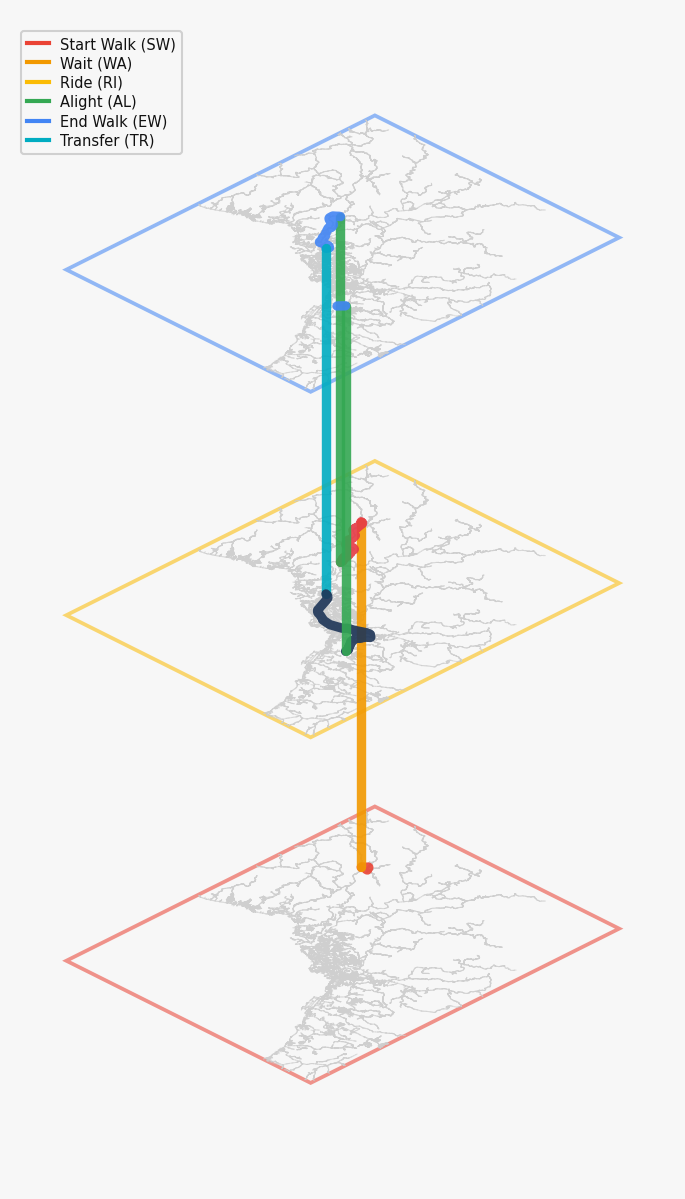

In [6]:
print("Searching for a journey containing a transfer...")
found = False
journey = []
for _ in range(500):
    start = ddm.get_point()
    end = ddm.get_point()
    if start and end and start != end:
        path = tg.findShortestJourney(start, end)
        if path and any(e.id.startswith("TR") for e in path):
            journey = path
            found = True
            break

if found:
    print(f"Found a valid transfer journey with {len(journey)} edge transitions!")
    for idx, edge in enumerate(journey):
        print(f"  Segment {idx+1}: {edge.id:<20} | Cost: {edge.weight:.2f} EIVM")
        
    journey_vis = TravelGraph3DVisualizer(tg.travel_graph, highlight_edges=journey, mode="light", edge_thickness=0.8, journey_thickness=4.5)
    img_journey = journey_vis.draw(
        display_walk=True, display_wait=True, display_ride=True, display_alight=True, display_end_walk=True, display_transfer=True, 
        display_direct=False, legend_on=True
    )
    img_journey.save("results_and_discussion/images/sample_journey_transfer.png")
    display(img_journey)
else:
    print("Could not find a transfer journey stochastically. Rendering a direct path instead.")
    start = ddm.get_point()
    end = ddm.get_point()
    path = tg.findShortestJourney(start, end)
    if path:
        journey_vis = TravelGraph3DVisualizer(tg.travel_graph, highlight_edges=path, mode="light", edge_thickness=0.8, journey_thickness=4.5)
        img_journey = journey_vis.draw(legend_on=True)
        img_journey.save("results_and_discussion/images/sample_journey_direct.png")
        display(img_journey)

## 3. Agent-Based Temporal Simulation Telemetry Snapshots
We run a manual simulation loop, spawning passenger agents stochastically and tracking vehicle movement tick-by-tick. We capture snapshots of the network state at ticks 10, 40, 80, and 120, showing waiting passengers (red circles), riding passengers (green crosses), and jeepney positions (blue triangles) moving along their route paths.

In [ ]:
import math
from utils.passenger_generator import PassengerGenerator
from utils.simulation import Simulation
from utils.passenger import Passenger
from utils.directed_edge import EDGE_TR

with open(yaml_path, 'r', encoding='utf-8') as f:
    config_dict = yaml.safe_load(f)

def make_jeep_sys(routes, num_jeeps=8):
    jeeps = []
    jeeps_per_route = max(1, num_jeeps // len(routes))
    for r in routes:
        for _ in range(jeeps_per_route):
            start_coord = (r.path[0].start.lon, r.path[0].start.lat)
            jeeps.append(Jeep(r, curr_pos=start_coord, speed=40.0, max_capacity=16))
    return JeepSystem(jeeps=jeeps, routes=routes, weight_tolerance=50.0, equidistant_spawn=True)

def has_transfer(p):
    return any(e._edge_type == EDGE_TR for e in p.journey)

def snap(label, tick, p, jeep_sys):
    return {
        "label": label,
        "tick":  tick,
        "p_lon": p.curr_lon,
        "p_lat": p.curr_lat,
        "state": p.state,
        "jeeps": [(j.curr_pos[0], j.curr_pos[1]) for j in jeep_sys.jeeps],
    }

generate_dummy_yaml(yaml_path, **{
    "simulation.num_ticks": 3000,
    "simulation.total_allocatable_jeeps": 25,
    "cg_pkl": "results_and_discussion/pkl/profile_p1.pkl",
    "ddm_pkl": "results_and_discussion/pkl/ddm_8am.pkl",
    "travel_graph.transfer_wt": 15.0,
    "seconds_per_tick": 300
})

with open(yaml_path, 'r', encoding='utf-8') as f:
    config_dict = yaml.safe_load(f)

passenger_generator = PassengerGenerator(
    tg=tg, sampler=ddm, rate_per_hour=250.0, stdev=10.0, speed=5.0
)
jeep_sys = make_jeep_sys(routes, num_jeeps=6)
sim_instance = Simulation(
    city_query="Iligan City",
    bounds=tg.cg.get_bounds(),
    jeep_system=jeep_sys,
    passenger_generator=passenger_generator,
    max_ticks=3000,
    beta_penalty=2.0,
    config=config_dict
)

print("Running simulation — tracking a transfer-journey passenger...")

tracked    = None
prev_state = None
snapshots  = []

# Sequential slot machine — each entry is (label, from_state, to_state, ride_count_required)
# ride_count tracks how many RIDING→not-RIDING transitions have completed,
# so we can tell first alight from second alight, first wait from transfer wait, etc.
SLOT_SEQUENCE = [
    # label                        from        to                   min_rides
    ("Spawned at origin",          None,        Passenger.WALKING,  0),
    ("Waiting for first jeep",     Passenger.WALKING,  Passenger.WAITING,  0),
    ("Riding first jeep",          Passenger.WAITING,  Passenger.RIDING,   0),
    ("Alighted — walking",         Passenger.RIDING,   Passenger.WALKING,  0),
    ("Waiting to transfer",        Passenger.WALKING,  Passenger.WAITING,  1),
    ("Riding second jeep",         Passenger.WAITING,  Passenger.RIDING,   1),
    ("Walking to destination",     Passenger.RIDING,   Passenger.WALKING,  2),
    ("Arrived at destination",     Passenger.WALKING,  Passenger.DONE,     2),
]

slot_idx   = 0
ride_count = 0   # increments each time passenger leaves RIDING state

MAX_TICKS = 10000
for tick in range(1, MAX_TICKS + 1):
    sim_instance.update()
    if tracked is not None and tick % 10 == 0:
        print(f"  tick={tick} state={tracked.state} ride_count={ride_count} "
            f"edge_idx={tracked._edge_idx}/{len(tracked.journey)} "
            f"jeep={tracked.current_jeep is not None}")
    # Find tracked passenger
    if tracked is None:
        for p in sim_instance.passenger_generator.passengers:
            if has_transfer(p):
                tracked = p
                prev_state = None
                print(f"  Tick {tick}: tracking {tracked.id[:8]}... "
                      f"({len(tracked.journey)}-edge journey with transfer)")
                break

    if tracked is None:
        continue

    cur_state = tracked.state

    # Update ride_count when passenger leaves RIDING
    if prev_state == Passenger.RIDING and cur_state != Passenger.RIDING:
        ride_count += 1

    # Check if the current slot's transition just fired
    if slot_idx < len(SLOT_SEQUENCE):
        label, from_st, to_st, min_rides = SLOT_SEQUENCE[slot_idx]

        transition_fired = (prev_state == from_st and cur_state == to_st) \
                           if from_st is not None \
                           else (cur_state == to_st and prev_state is None)

        if transition_fired and ride_count >= min_rides:
            snapshots.append(snap(label, tick, tracked, sim_instance.jeep_system))
            print(f"  Tick {tick}: slot {slot_idx+1}/{len(SLOT_SEQUENCE)} — '{label}'")
            slot_idx += 1

    if slot_idx >= len(SLOT_SEQUENCE):
        print("  All slots captured.")
        break

    prev_state = cur_state

if not snapshots:
    raise RuntimeError("No snapshots captured — try increasing MAX_TICKS or passenger spawn rate.")

print(f"\nCaptured {len(snapshots)} snapshots.")

# ── Plot ──────────────────────────────────────────────────────────────────────
N_COLS = 3
N_ROWS = math.ceil(len(snapshots) / N_COLS)
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(7 * N_COLS, 6 * N_ROWS))
axes = np.array(axes).flatten()

PASSENGER_COLORS = {
    Passenger.WALKING: "#facc15",
    Passenger.WAITING: "#ef4444",
    Passenger.RIDING:  "#22c55e",
    Passenger.DONE:    "#a855f7",
}

route_colors = plt.colormaps['Set1'](np.linspace(0, 1, len(routes)))

for idx, s in enumerate(snapshots):
    ax = axes[idx]

    for e in random.sample(list(cg.graph), min(1000, len(cg.graph))):
        ax.plot([e.start.lon, e.end.lon], [e.start.lat, e.end.lat],
                color='#cbd5e1', alpha=0.15, linewidth=0.5)

    for r_idx, r in enumerate(routes):
        lons = [e.start.lon for e in r.path] + [r.path[-1].end.lon]
        lats = [e.start.lat for e in r.path] + [r.path[-1].end.lat]
        ax.plot(lons, lats, color=route_colors[r_idx], linewidth=2.0, alpha=0.45)

    j_lons = [lon for lon, lat in s["jeeps"]]
    j_lats = [lat for lon, lat in s["jeeps"]]
    if j_lons:
        ax.scatter(j_lons, j_lats, color='#1d4ed8', marker='^',
                   s=130, zorder=10, label='Jeepney')

    p_color = PASSENGER_COLORS.get(s["state"], "#ffffff")
    ax.scatter([s["p_lon"]], [s["p_lat"]], color=p_color,
               marker='*', s=350, zorder=15,
               edgecolors='black', linewidths=0.8, label='Passenger')

    ax.set_title(f"Tick {s['tick']}  —  {s['label']}", fontsize=11, fontweight='bold')
    ax.axis("off")
    if idx == 0:
        ax.legend(loc="upper left", frameon=True, facecolor='#f8fafc', fontsize=9)

for idx in range(len(snapshots), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
os.makedirs("results_and_discussion/images", exist_ok=True)
plt.savefig("results_and_discussion/images/passenger_journey_snapshots.png", dpi=300)
display(fig)
plt.close(fig)

[INFO] Generating dummy YAML at configs/dummy_nb1.yaml with overrides: {'simulation.num_ticks': 3000, 'simulation.total_allocatable_jeeps': 25, 'cg_pkl': 'results_and_discussion/pkl/profile_p1.pkl', 'ddm_pkl': 'results_and_discussion/pkl/ddm_8am.pkl', 'travel_graph.transfer_wt': 15.0, 'seconds_per_tick': 300}
Running simulation — tracking a transfer-journey passenger...
  Tick 123: tracking P3ef76e9... (967-edge journey with transfer)
  Tick 123: slot 1/8 — 'Spawned at origin'
  tick=130 state=0 ride_count=0 edge_idx=1/967 jeep=False
  tick=140 state=0 ride_count=0 edge_idx=2/967 jeep=False
  tick=150 state=0 ride_count=0 edge_idx=6/967 jeep=False
  tick=160 state=0 ride_count=0 edge_idx=9/967 jeep=False
  tick=170 state=0 ride_count=0 edge_idx=10/967 jeep=False
  tick=180 state=0 ride_count=0 edge_idx=11/967 jeep=False
  tick=190 state=0 ride_count=0 edge_idx=13/967 jeep=False
  tick=200 state=0 ride_count=0 edge_idx=14/967 jeep=False
  tick=210 state=0 ride_count=0 edge_idx=14/967 je

<Figure size 2100x1200 with 6 Axes>